# 04 | **Final figures for DLS analysis**

## Objectives:

**1.** Generate clean, publication-oriented figures

**2.** Summarize DLS size, PDI, autocorrelation, and extracted features

**3.** Export final figures to outputs/figures/final

---

This notebook should not perform exploratory analysis.

It should only use processed/curated datasets from previous notebooks.

## Initial setup

### Imports

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt

from matplotlib.ticker import MultipleLocator, AutoMinorLocator

### Pandas config

In [35]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

### Projects paths

In [36]:
# roots paths
ROOT_DIR = Path('../../').resolve()  
EXP_DIR  = Path('..').resolve()

# files paths
STYLE_DIR = ROOT_DIR / 'src' / 'kirsten.mplstyle'
DATA_PROCESSED_DIR = EXP_DIR / 'data' / 'processed'
FIGURES_DIR = EXP_DIR / "outputs" / "figures" / "final"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("EXP_DIR:", EXP_DIR)
print("DATA_PROCESSED_DIR:", DATA_PROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

plt.style.use(STYLE_DIR)  # custom matplotlib style for plots

ROOT_DIR: D:\Documents\GitHub\dls-analysis
EXP_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution
DATA_PROCESSED_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\data\processed
FIGURES_DIR: D:\Documents\GitHub\dls-analysis\cars_in_solution\outputs\figures\final


### Load processed data

In [37]:
df_dls = pd.read_csv(DATA_PROCESSED_DIR / "dls_filtered.csv")
df_features = pd.read_csv(DATA_PROCESSED_DIR / "dls_curve_features_clean.csv")
df_corr_long = pd.read_csv(DATA_PROCESSED_DIR / "correlations_long.csv")

In [38]:
print("df_dls:", df_dls.shape)
print("df_features:", df_features.shape)
print("df_corr_long:", df_corr_long.shape)

df_dls: (28, 26)
df_features: (34, 23)
df_corr_long: (8640, 4)


### Limpeza leve e labels bonitos

In [39]:
# Keep only carrageenan-containing samples for main figures
df_dls_carr = df_dls[df_dls["carrageenan"].notna()].copy()
df_feat_carr = df_features[df_features["carrageenan"].notna()].copy()

# Ordered categorical variables
carrageenan_order = ["kappa", "iota", "lambda"]
matrix_order = ["water", "medium"]

carrageenan_labels = {
    "kappa": "κ-carrageenan",
    "iota": "ι-carrageenan",
    "lambda": "λ-carrageenan"
}

matrix_labels = {
    "water": "Water",
    "medium": "α-MEM + FBS"
}

df_dls_carr["carrageenan_label"] = df_dls_carr["carrageenan"].map(carrageenan_labels)
df_dls_carr["matrix_label"] = df_dls_carr["matrix"].map(matrix_labels)

df_feat_carr["carrageenan_label"] = df_feat_carr["carrageenan"].map(carrageenan_labels)
df_feat_carr["matrix_label"] = df_feat_carr["matrix"].map(matrix_labels)

df_dls_carr["carrageenan_label"] = pd.Categorical(
    df_dls_carr["carrageenan_label"],
    categories=[carrageenan_labels[c] for c in carrageenan_order],
    ordered=True
)

df_feat_carr["carrageenan_label"] = pd.Categorical(
    df_feat_carr["carrageenan_label"],
    categories=[carrageenan_labels[c] for c in carrageenan_order],
    ordered=True
)

df_dls_carr["matrix_label"] = pd.Categorical(
    df_dls_carr["matrix_label"],
    categories=[matrix_labels[m] for m in matrix_order],
    ordered=True
)

df_feat_carr["matrix_label"] = pd.Categorical(
    df_feat_carr["matrix_label"],
    categories=[matrix_labels[m] for m in matrix_order],
    ordered=True
)

In [40]:
matched_concentration = {
    "kappa": "100 ug/mL",
    "iota": "20 ug/mL",
    "lambda": "35 ug/mL"
}

df_dls_matched = df_dls_carr[
    df_dls_carr.apply(
        lambda row: row["concentration_label"] == matched_concentration.get(row["carrageenan"]),
        axis=1
    )
].copy()

df_feat_matched = df_feat_carr[
    df_feat_carr.apply(
        lambda row: row["concentration_label"] == matched_concentration.get(row["carrageenan"]),
        axis=1
    )
].copy()

print("df_dls_matched:", df_dls_matched.shape)
print("df_feat_matched:", df_feat_matched.shape)

df_dls_matched: (15, 28)
df_feat_matched: (18, 25)


In [41]:
display_label_map = {
    "kappa":  r"$\kappa$–1S",
    "iota":   r"$\iota$–2S",
    "lambda": r"$\lambda$–3S"
}

df_dls_carr["display_label"] = df_dls_carr["carrageenan"].map(display_label_map)
df_feat_carr["display_label"] = df_feat_carr["carrageenan"].map(display_label_map)

# se estiver usando os datasets matched:
df_dls_matched["display_label"] = df_dls_matched["carrageenan"].map(display_label_map)
df_feat_matched["display_label"] = df_feat_matched["carrageenan"].map(display_label_map)

### Paleta

In [106]:
matrix_palette = {
    "Water": "#D94C8A",
    "α-MEM + FBS": "#2F80C9"
}

concentration_palette = {
    "1 mg/mL":   "#BFBFBF",
    "100 ug/mL": "#FC92BB",
    "20 ug/mL":  "#52BEF0",
    "35 ug/mL":  "#F0C652"
}

color_by_carrageenan = {
    "kappa":  "#F0528E",   # trocar pelo teu hex
    "iota":   "#1788BD",   # trocar pelo teu hex
    "lambda": "#F1B545"    # trocar pelo teu hex
}

marker_by_matrix = {
    "water": "v",
    "medium": "^"
}

## Z-average e PDI

### Função de boxplot + pontos

In [61]:
def summarize_metric(df, value_col, group_cols):
    out = (
        df.groupby(group_cols, as_index=False)[value_col]
        .agg(["mean", "std", "count"])
        .reset_index()
    )
    out = out.rename(columns={"std": "SD", "count": "n"})
    out["SEM"] = out["SD"] / np.sqrt(out["n"])
    
    return out

In [62]:
def style_axis_like_ars(ax, y_major=None, y_minor_divisions=4, yscale=None):
    if yscale is not None:
        ax.set_yscale(yscale)

    # grids
    ax.grid(axis="y", which="major", linestyle="-", linewidth=0.5, alpha=.75, zorder=-10)
    ax.grid(axis="y", which="minor", linestyle=":", linewidth=0.5, alpha=.75, zorder=-10)

    # locators only for linear scale
    if yscale is None:
        if y_major is not None:
            ax.yaxis.set_major_locator(MultipleLocator(y_major))
        ax.yaxis.set_minor_locator(AutoMinorLocator(y_minor_divisions))

In [67]:
def plot_metric(
    df,
    value_col,
    ylabel,
    title,
    save_stub=None,
    error_mode="SD",   # "SD" ou "SEM"
    ylim_water=None,
    ylim_medium=None,
    y_major_water=None,
    y_major_medium=None,
    yscale_water=None,
    yscale_medium=None,
    plot_raw_points=True,
):
    order_carr = ["kappa", "iota", "lambda"]
    order_labels = [display_label_map[c] for c in order_carr]
    xpos = {lab: i for i, lab in enumerate(order_labels)}

    # estatística resumida
    stats = summarize_metric(
        df=df,
        value_col=value_col,
        group_cols=["matrix", "carrageenan", "display_label"]
    )

    MARKER_SIZE = 14
    fig, axes = plt.subplots(1, 2, figsize=(9.5, 5.8), sharex=True, sharey=False)

    panel_info = [
        ("water",  "Water",       ylim_water,  y_major_water,  yscale_water),
        ("medium", r"$\alpha$-MEM + FBS", ylim_medium, y_major_medium, yscale_medium),
    ]

    rng = np.random.default_rng(42)

    for ax, (matrix, panel_title, ylim, y_major, yscale) in zip(axes, panel_info):
        sub_raw = df[df["matrix"] == matrix].copy()
        sub_stats = stats[stats["matrix"] == matrix].copy()

        for carr in order_carr:
            lab = display_label_map[carr]
            x = xpos[lab]

            # cor
            if "color_by_carr_matrix" in globals():
                c = color_by_carr_matrix[(carr, matrix)]
            else:
                c = color_by_carrageenan[carr]

            # replicatas brutas
            vals = pd.to_numeric(
                sub_raw.loc[sub_raw["display_label"] == lab, value_col],
                errors="coerce"
            ).dropna()

            if plot_raw_points and len(vals) > 0:
                xj = x + rng.uniform(-0.08, 0.08, size=len(vals))
                ax.scatter(
                    xj, vals,
                    s=36,
                    facecolor=c,
                    edgecolor="white",
                    linewidth=0.7,
                    alpha=0.55,
                    zorder=1
                )

            # mean ± error
            row = sub_stats[
                (sub_stats["carrageenan"] == carr) &
                (sub_stats["display_label"] == lab)
            ]

            if len(row) == 0:
                continue

            y = float(row["mean"].iloc[0])
            err = float(row[error_mode].iloc[0]) if pd.notna(row[error_mode].iloc[0]) else 0.0

            ax.errorbar(
                x=x,
                y=y,
                yerr=err,
                fmt=marker_by_matrix[matrix],
                markersize=MARKER_SIZE,
                markerfacecolor=c,
                markeredgecolor="white",
                markeredgewidth=1.25,
                ecolor=c,
                elinewidth=1.0,
                capsize=6,
                capthick=1.0,
                zorder=4
            )

        ax.set_title(panel_title)
        ax.set_xticks(range(len(order_labels)))
        ax.set_xticklabels(order_labels)
        ax.set_xlabel("")
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_xlim(-0.5, len(order_labels) - 0.5)

        style_axis_like_ars(
            ax=ax,
            y_major=y_major,
            y_minor_divisions=4,
            yscale=yscale
        )

    axes[0].set_ylabel(ylabel)
    fig.suptitle(title)

    plt.tight_layout()

    if save_stub is not None:
        plt.savefig(FIGURES_DIR / f"{save_stub}.png", dpi=600, bbox_inches="tight")
        plt.savefig(FIGURES_DIR / f"{save_stub}.svg", bbox_inches="tight")

### Figure 1

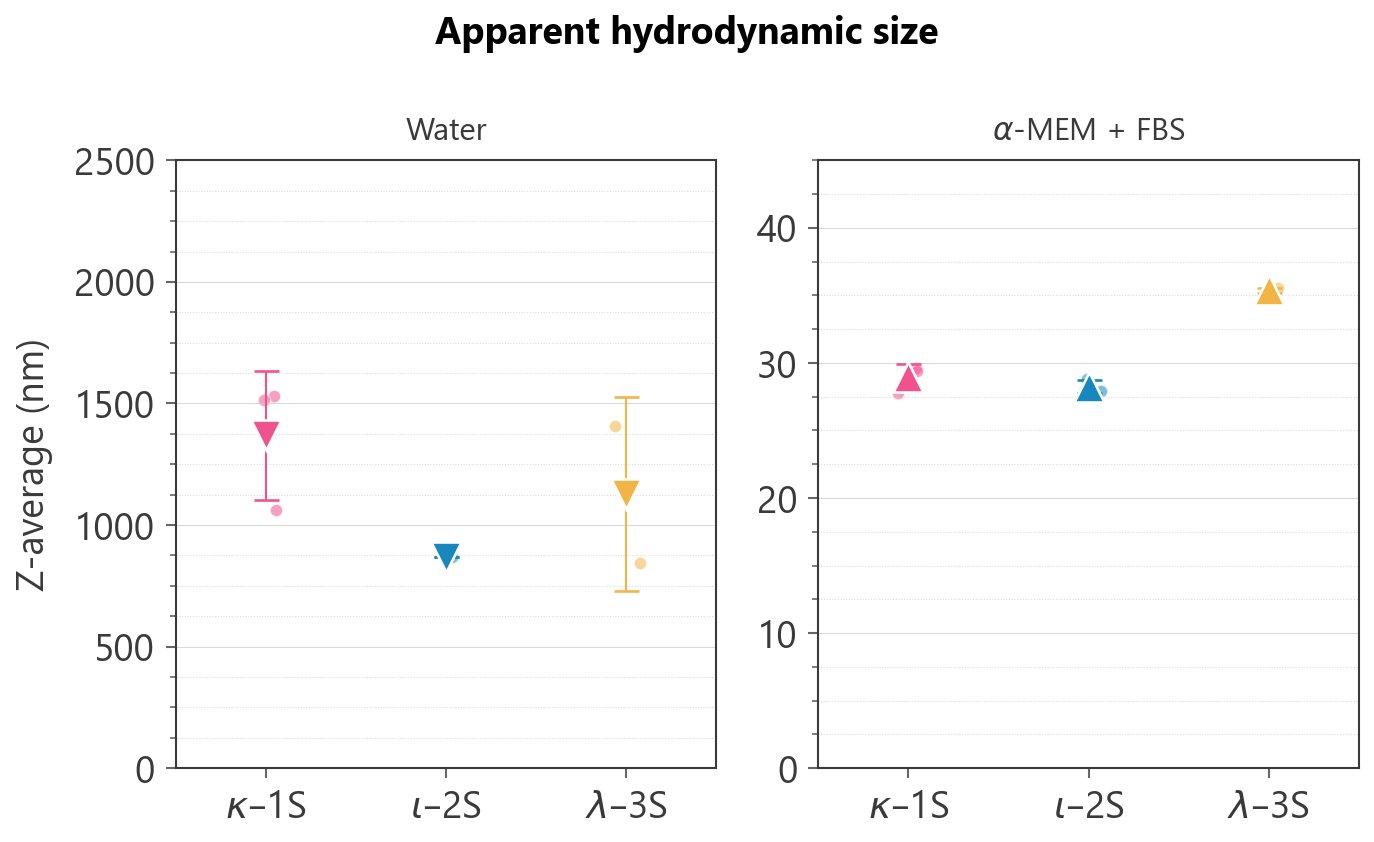

In [68]:
plot_metric(
    df=df_dls_matched,
    value_col="Z_Average_d_nm",
    ylabel="Z-average (nm)",
    title="Apparent hydrodynamic size",
    save_stub="figure_01_zaverage_split_ars_style",
    error_mode="SD",
    ylim_water=(0, 2500),
    ylim_medium=(0, 45),
    y_major_water=500,
    y_major_medium=10,
    plot_raw_points=True
)

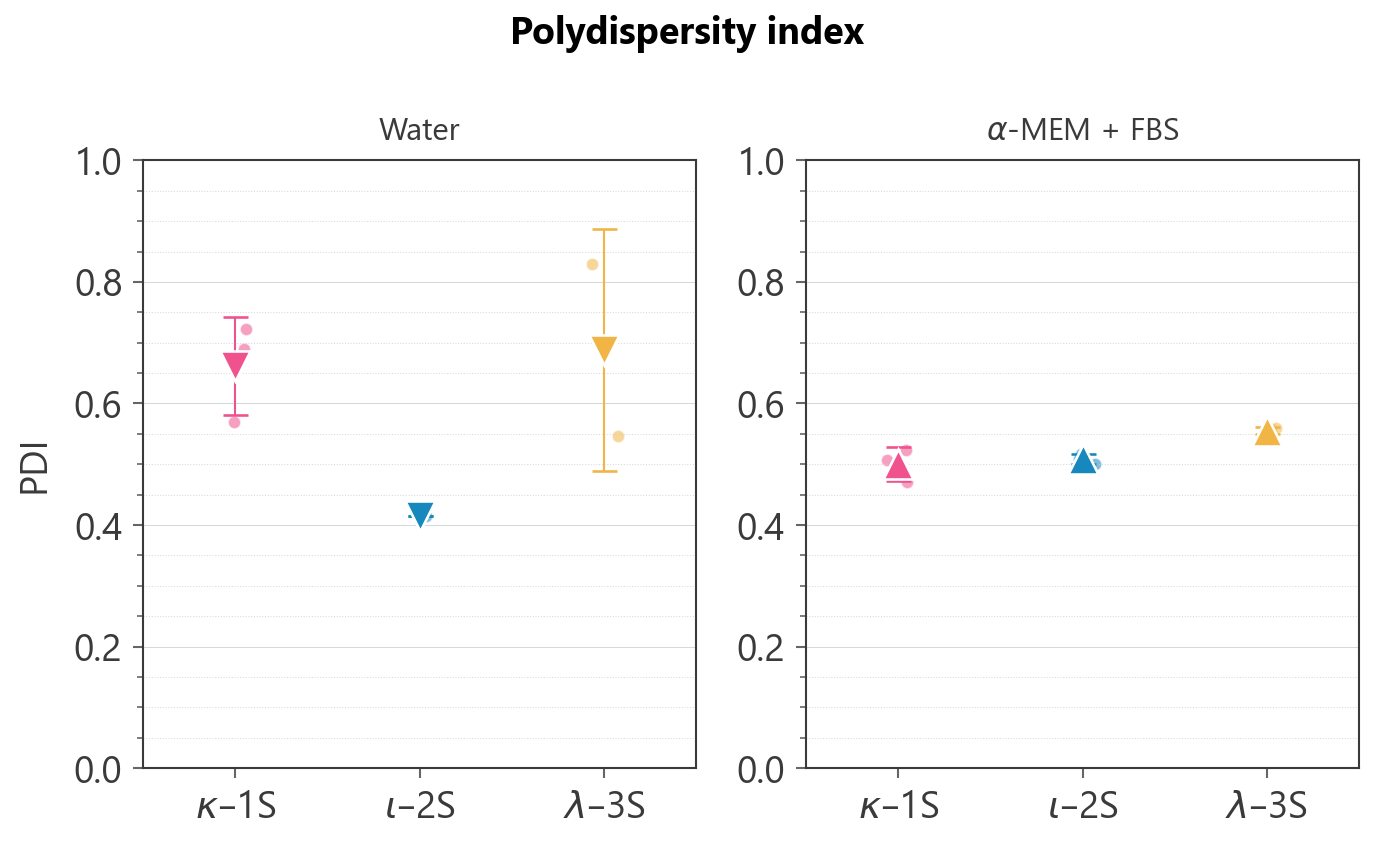

In [72]:
plot_metric(
    df=df_dls_matched,
    value_col="PdI",
    ylabel="PDI",
    title="Polydispersity index",
    save_stub="figure_02_pdi_split_ars_style",
    error_mode="SD",
    ylim_water=(0, 1),
    ylim_medium=(0, 1),
    y_major_water=0.2,
    y_major_medium=0.2,
    plot_raw_points=True
)

## Features da autocorrelação

### Identificar nome da coluna de tau

In [45]:
if "corr_tau50_delay_units" in df_feat_carr.columns:
    tau50_col = "corr_tau50_delay_units"
elif "corr_tau50_s" in df_feat_carr.columns:
    tau50_col = "corr_tau50_s"
else:
    raise ValueError("No tau50 column found.")

tau50_col

'corr_tau50_delay_units'

### Figure 2

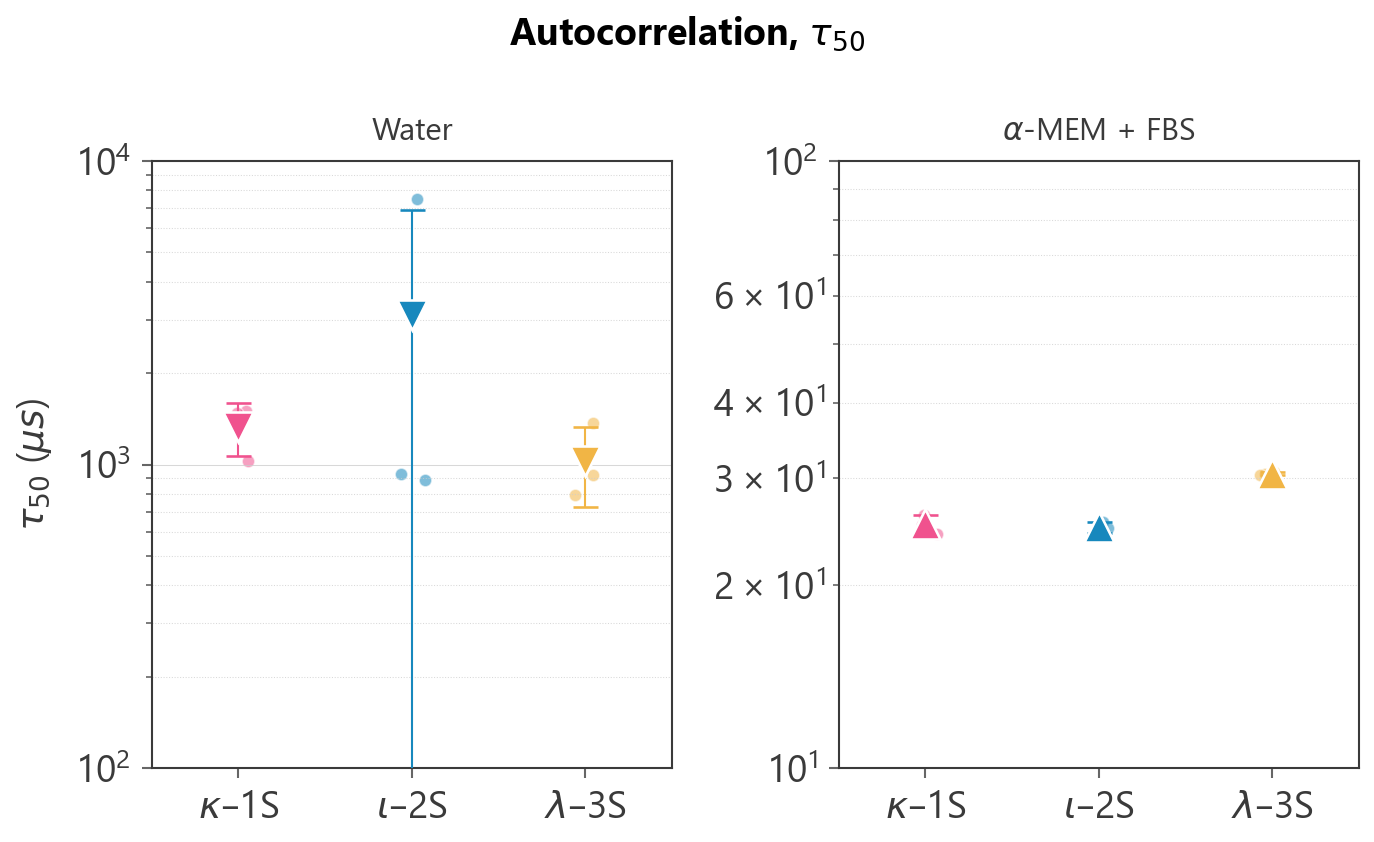

In [89]:
plot_metric(
    df=df_feat_matched,
    value_col=tau50_col,
    ylabel=r"$\tau_{50}$ ($\mu s$)",
    title=r"Autocorrelation, $\tau_{50}$",
    save_stub="figure_03_tau50_split_ars_style",
    error_mode="SD",
    ylim_water=(10**2, 10**4),
    ylim_medium=(10**1, 10**2),
    yscale_water="log",
    yscale_medium="log",
    plot_raw_points=True
)

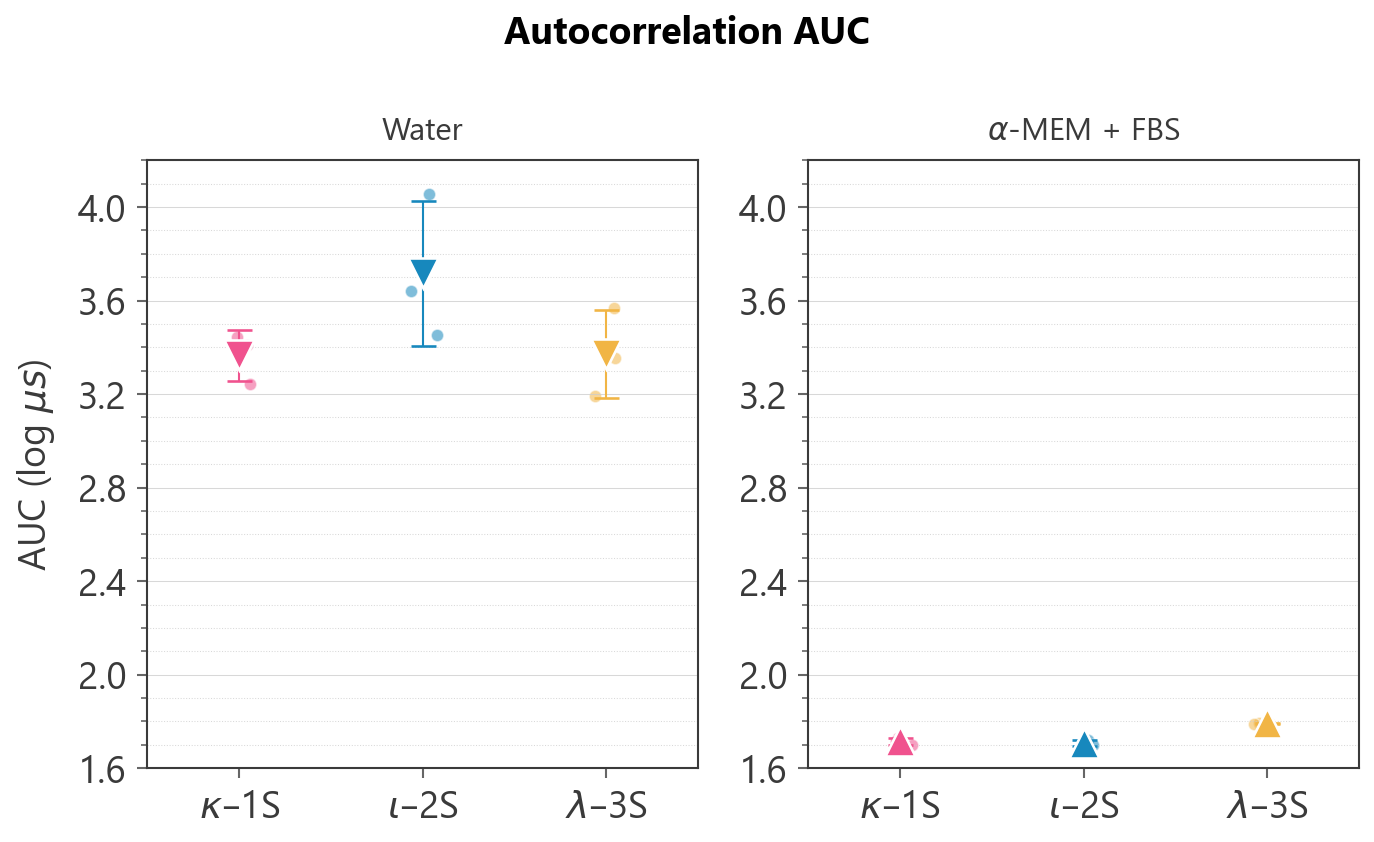

In [93]:
plot_metric(
    df=df_feat_matched,
    value_col="corr_auc_logx",
    ylabel="AUC (log $\\mu s$)",
    title="Autocorrelation AUC",
    save_stub="figure_04_auc_split_ars_style",
    error_mode="SD",
    ylim_water=(1.6, 4.2),
    ylim_medium=(1.6, 4.2),
    # ylim_water=(3.0, 4.2),
    # ylim_medium=(1.6, 1.9),
    y_major_water=0.4,
    y_major_medium=0.4,
    plot_raw_points=True
)

## Água: efeito de concentração

### subset água

In [47]:
df_feat_water = df_feat_carr[df_feat_carr["matrix"] == "water"].copy()

df_feat_water["concentration_label"] = pd.Categorical(
    df_feat_water["concentration_label"],
    categories=["1 mg/mL", "100 ug/mL", "20 ug/mL", "35 ug/mL"],
    ordered=True
)

### Figure 3

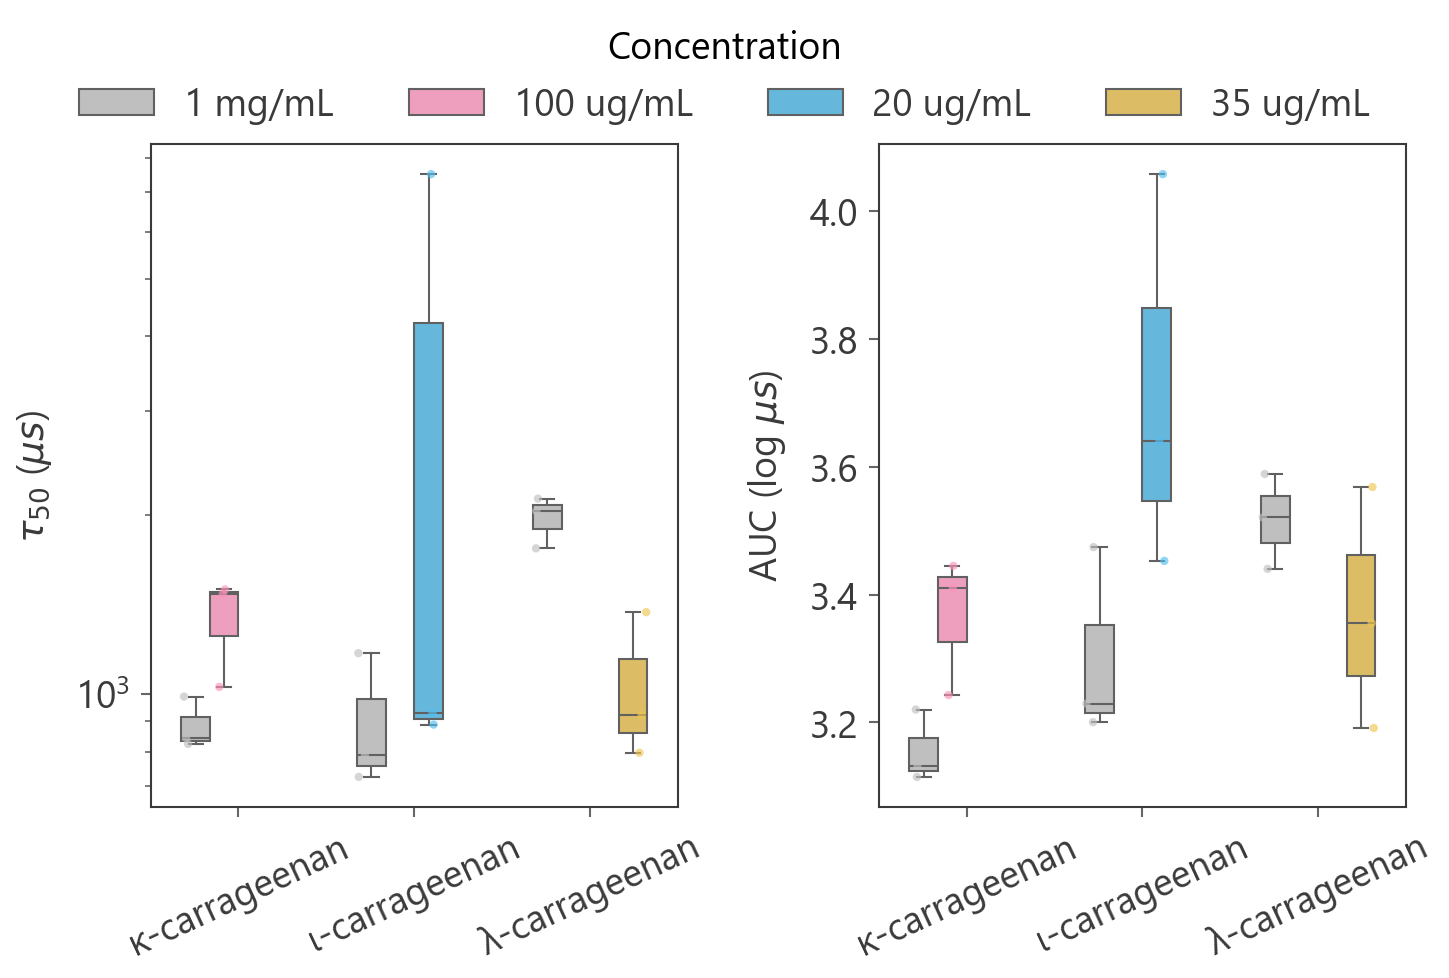

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharex=True)

sns.boxplot(
    data=df_feat_water,
    x="carrageenan_label",
    y=tau50_col,
    hue="concentration_label",
    palette=concentration_palette,
    ax=axes[0],
    width=0.65,
    fliersize=0,
    linewidth=1
)

sns.stripplot(
    data=df_feat_water,
    x="carrageenan_label",
    y=tau50_col,
    hue="concentration_label",
    dodge=True,
    ax=axes[0],
    palette=concentration_palette,
    alpha=0.65,
    size=4,
    legend=False
)

axes[0].set_yscale("log")
axes[0].set_xlabel("")
axes[0].set_ylabel("$\\tau_{50}$ ($\\mu s$)")
# axes[0].set_title("A")

sns.boxplot(
    data=df_feat_water,
    x="carrageenan_label",
    y="corr_auc_logx",
    hue="concentration_label",
    palette=concentration_palette,
    ax=axes[1],
    width=0.65,
    fliersize=0,
    linewidth=1
)

sns.stripplot(
    data=df_feat_water,
    x="carrageenan_label",
    y="corr_auc_logx",
    hue="concentration_label",
    dodge=True,
    ax=axes[1],
    palette=concentration_palette,
    alpha=0.65,
    size=4,
    legend=False
)

axes[1].set_xlabel("")
axes[1].set_ylabel("AUC (log $\\mu s$)")
# axes[1].set_title("B")

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()

fig.legend(
    handles,
    labels,
    title="Concentration",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=4
)

for ax in axes:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_03_water_concentration_features.png", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "figure_03_water_concentration_features.svg", bbox_inches="tight")

## Autocorrelation curves

### Anexar metadados à autocorrelação

In [49]:
metadata_cols = [
    "Sample_Name",
    "sample_base",
    "matrix",
    "carrageenan",
    "concentration_label",
    "replicate"
]

df_corr = df_corr_long.drop(
    columns=[c for c in metadata_cols if c in df_corr_long.columns and c != "Sample_Name"],
    errors="ignore"
).merge(
    df_dls[metadata_cols],
    on="Sample_Name",
    how="left"
)

df_corr = df_corr[
    df_corr["carrageenan"].notna()
].copy()

df_corr["carrageenan_label"] = df_corr["carrageenan"].map(carrageenan_labels)
df_corr["matrix_label"] = df_corr["matrix"].map(matrix_labels)

display(df_corr.head())

,Sample_Name,point_index,correlation_value,delay_time_s,sample_base,matrix,carrageenan,concentration_label,replicate,carrageenan_label,matrix_label
0,k_1s-100ug_mL 1,1,0.0897,0.5,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0,κ-carrageenan,Water
1,k_1s-100ug_mL 1,2,0.0946,1.0,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0,κ-carrageenan,Water
2,k_1s-100ug_mL 1,3,0.0952,1.5,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0,κ-carrageenan,Water
3,k_1s-100ug_mL 1,4,0.0967,2.0,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0,κ-carrageenan,Water
4,k_1s-100ug_mL 1,5,0.0949,2.5,k_1s-100ug_mL,water,kappa,100 ug/mL,1.0,κ-carrageenan,Water


### Normalizar curvas de autocorrelação

In [50]:
def normalize_correlation_curve(y, n_start=5, n_end=10):
    y = np.asarray(y, dtype=float)
    
    y_start = np.nanmedian(y[:min(n_start, len(y))])
    y_end = np.nanmedian(y[-min(n_end, len(y)):])
    
    denom = y_start - y_end
    
    if np.isclose(denom, 0):
        return np.full_like(y, np.nan)
    
    return (y - y_end) / denom

### Perfil médio de autocorrelação por matriz/carragenana

In [51]:
records = []

for keys, subdf in df_corr.groupby(
    ["Sample_Name", "matrix", "matrix_label", "carrageenan", "carrageenan_label"],
    dropna=False
):
    sample_name, matrix, matrix_label, carrageenan, carrageenan_label = keys
    
    tmp = subdf[["delay_time_s", "correlation_value"]].copy()
    tmp["delay_time_s"] = pd.to_numeric(tmp["delay_time_s"], errors="coerce")
    tmp["correlation_value"] = pd.to_numeric(tmp["correlation_value"], errors="coerce")
    tmp = tmp.dropna()
    tmp = tmp[tmp["delay_time_s"] > 0]
    tmp = tmp.groupby("delay_time_s", as_index=False)["correlation_value"].mean()
    tmp = tmp.sort_values("delay_time_s")
    
    y_norm = normalize_correlation_curve(tmp["correlation_value"].to_numpy())
    
    for x, y in zip(tmp["delay_time_s"], y_norm):
        records.append({
            "Sample_Name": sample_name,
            "matrix": matrix,
            "matrix_label": matrix_label,
            "carrageenan": carrageenan,
            "carrageenan_label": carrageenan_label,
            "delay_time": x,
            "corr_norm": y
        })

df_corr_norm = pd.DataFrame(records)

corr_mean = (
    df_corr_norm
    .groupby(["matrix_label", "carrageenan_label", "delay_time"], as_index=False)
    .agg(
        corr_mean=("corr_norm", "mean"),
        corr_std=("corr_norm", "std"),
        n=("corr_norm", "count")
    )
)

display(corr_mean.head())

,matrix_label,carrageenan_label,delay_time,corr_mean,corr_std,n
0,Water,ι-carrageenan,0.5,0.990629,0.005171,4
1,Water,ι-carrageenan,1.0,1.004435,0.001662,4
2,Water,ι-carrageenan,1.5,1.001115,0.000939,4
3,Water,ι-carrageenan,2.0,0.999164,0.001672,4
4,Water,ι-carrageenan,2.5,0.998057,0.001432,4


### Figure 4

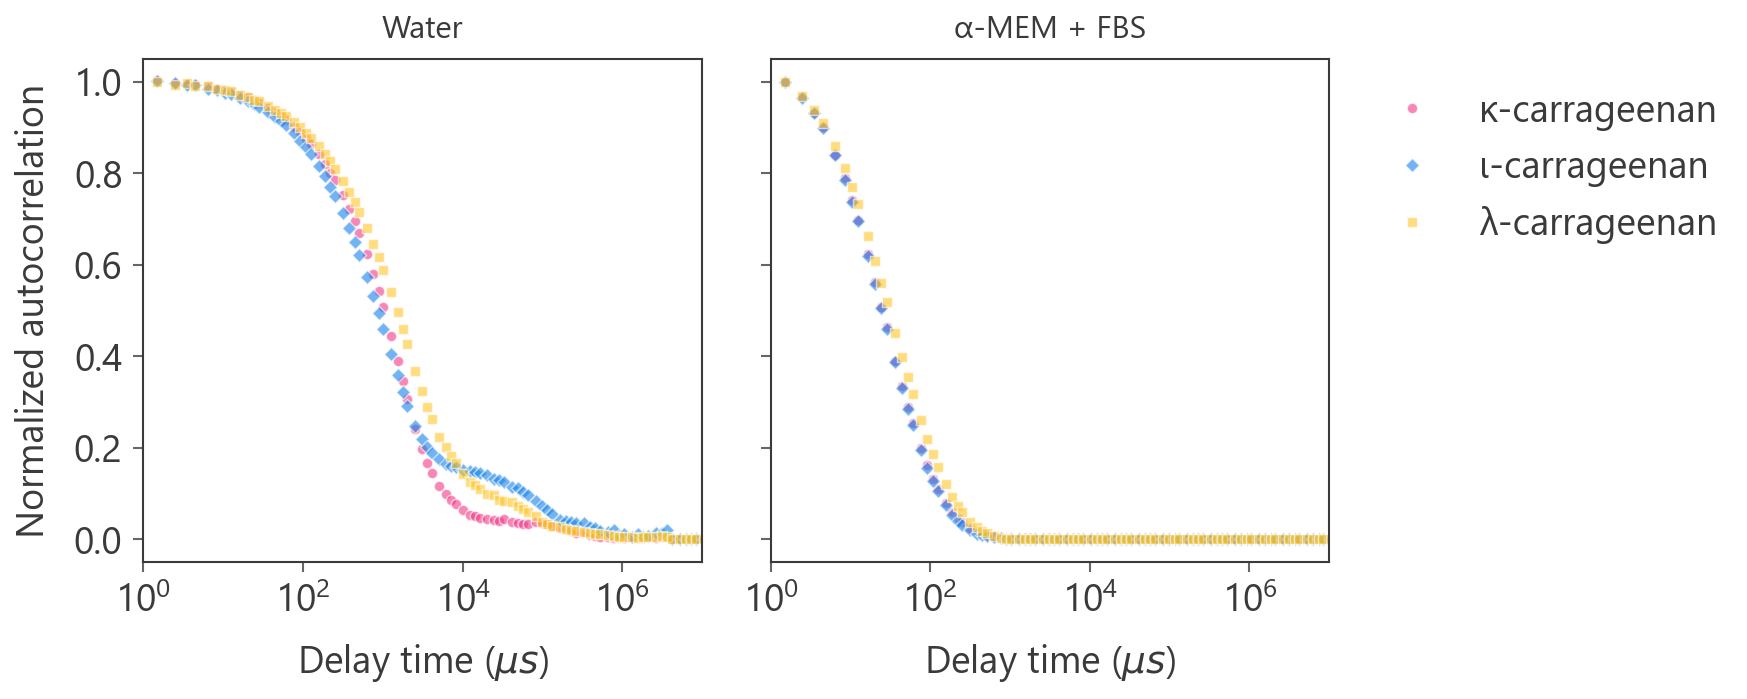

In [138]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for matrix_label, ax in zip(["Water", "α-MEM + FBS"], axes):
    sub = corr_mean[corr_mean["matrix_label"] == matrix_label]
    
    for carr_label, marker  in zip([carrageenan_labels[c] for c in carrageenan_order], ['o', 'D', 's']):
        tmp = sub[sub["carrageenan_label"] == carr_label].sort_values("delay_time")
        
        ax.plot(
            tmp["delay_time"][::2],
            tmp["corr_mean"][::2],
            marker=marker,
            markersize=5,
            alpha=0.6,
            linewidth=0,
            label=carr_label
        )
    
    ax.set_xscale("log")
    ax.set_xlim(1, 10**7); ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Delay time ($\\mu s$)")
    ax.set_title(matrix_label)

axes[0].set_ylabel("Normalized autocorrelation")
axes[1].legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "figure_04_autocorrelation_curves.png", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "figure_04_autocorrelation_curves.svg", bbox_inches="tight")

## Features de distribuição

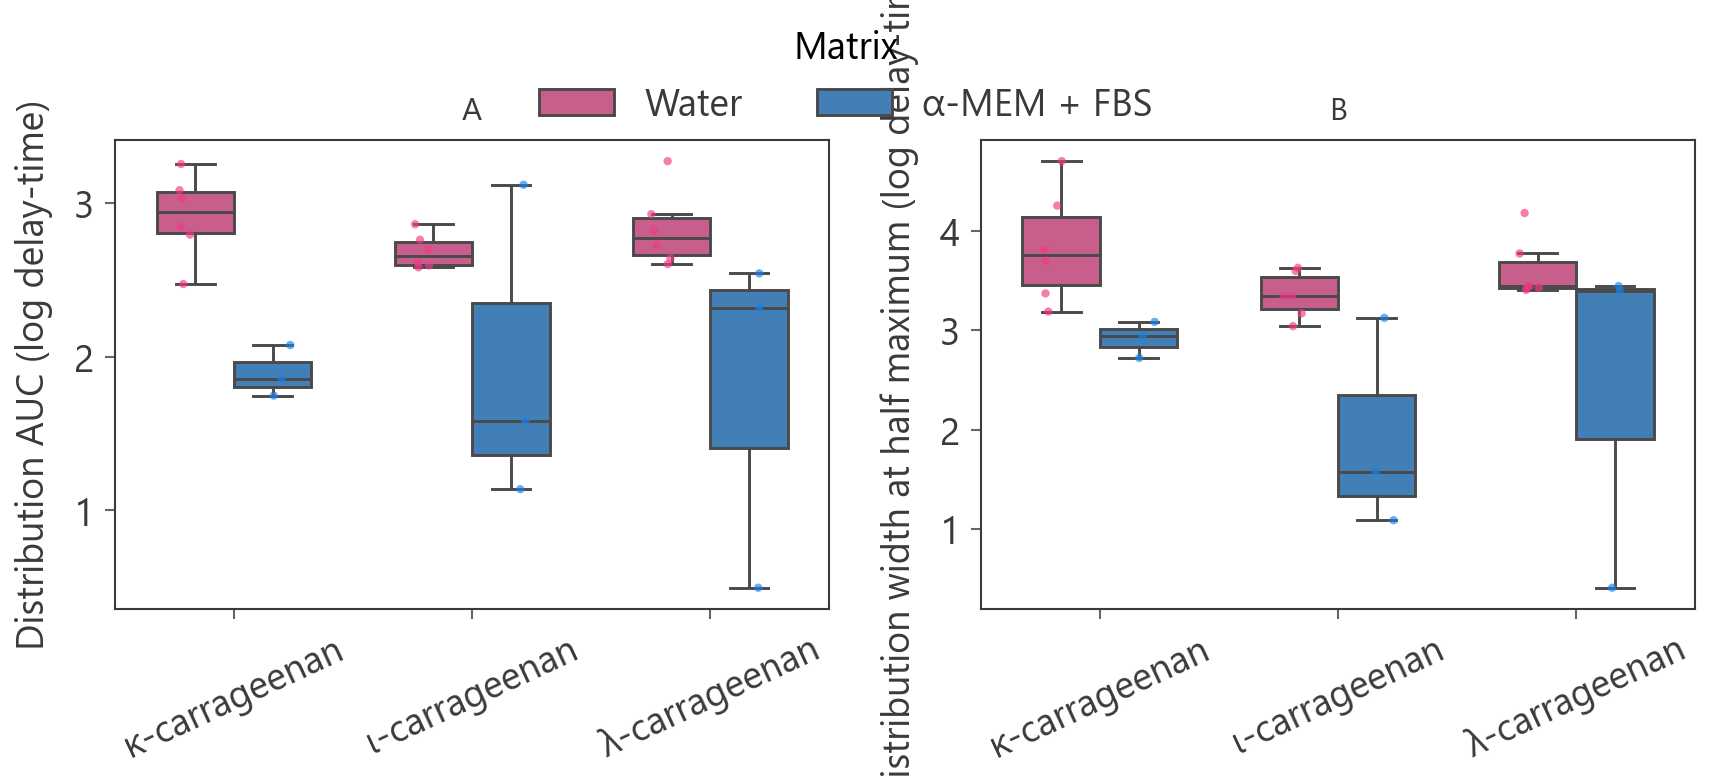

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

box_stripplot(
    data=df_feat_carr,
    x="carrageenan_label",
    y="dist_auc_logx",
    hue="matrix_label",
    ax=axes[0],
    palette=matrix_palette,
    ylabel="Distribution AUC (log delay-time)",
    title="A"
)

box_stripplot(
    data=df_feat_carr,
    x="carrageenan_label",
    y="dist_width_halfmax_logx",
    hue="matrix_label",
    ax=axes[1],
    palette=matrix_palette,
    ylabel="Distribution width at half maximum (log delay-time)",
    title="B"
)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()

fig.legend(
    handles[:2],
    labels[:2],
    title="Matrix",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2
)

for ax in axes:
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "supp_figure_distribution_features.png", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "supp_figure_distribution_features.svg", bbox_inches="tight")